DATA SET UTILIZADO: https://www.kaggle.com/datasets/mosapabdelghany/adult-income-prediction-dataset

# ETAPAS DO CRISP-DM


1. Business Understanding: Entende o problema de negócio e se é possível resolver com IA

2. Data Understanding: Importa dados. Entende os dados (EDA) e encontra possíveis problemas nos dados

3. Data Preparation: Trata dados, Seleciona dados (Feature Engineering) e Preprossamento de Dados (Encoding e Scale) e Separação de Dataset Train test split

4. Modeling: Treinar o modelo em si. Pelo menos 3. E realizar a Otimização de Hiperparametros.

5. Deploy e Pickle


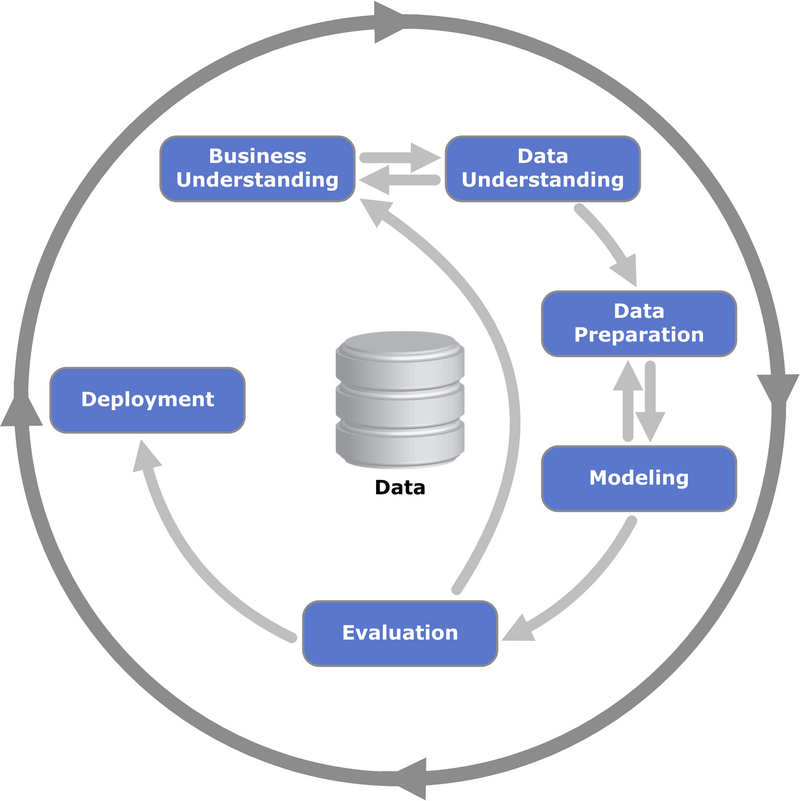

# BUSINESS UNDERSTANDING

Projeto para prever o salário de uma pessoa

In [2]:
# Import das libs
import pandas as pd
import plotly.express as px

# DATA UNDERSTANDING

In [3]:
#Import dos dados
df = pd.read_csv('adult.csv')

In [4]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## EDA - Entendendo os dados que temos

In [5]:
df.shape

(32561, 15)

In [6]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
df.describe(include="object")

,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [8]:
df['workclass'].unique()

array(['?', 'Private', 'State-gov', 'Federal-gov', 'Self-emp-not-inc',
       'Self-emp-inc', 'Local-gov', 'Without-pay', 'Never-worked'],
      dtype=object)

In [9]:
df['education'].unique()

array(['HS-grad', 'Some-college', '7th-8th', '10th', 'Doctorate',
       'Prof-school', 'Bachelors', 'Masters', '11th', 'Assoc-acdm',
       'Assoc-voc', '1st-4th', '5th-6th', '12th', '9th', 'Preschool'],
      dtype=object)

In [10]:
df['race'].unique()

array(['White', 'Black', 'Asian-Pac-Islander', 'Other',
       'Amer-Indian-Eskimo'], dtype=object)

In [11]:
df['native.country'].unique()

array(['United-States', '?', 'Mexico', 'Greece', 'Vietnam', 'China',
       'Taiwan', 'India', 'Philippines', 'Trinadad&Tobago', 'Canada',
       'South', 'Holand-Netherlands', 'Puerto-Rico', 'Poland', 'Iran',
       'England', 'Germany', 'Italy', 'Japan', 'Hong', 'Honduras', 'Cuba',
       'Ireland', 'Cambodia', 'Peru', 'Nicaragua', 'Dominican-Republic',
       'Haiti', 'El-Salvador', 'Hungary', 'Columbia', 'Guatemala',
       'Jamaica', 'Ecuador', 'France', 'Yugoslavia', 'Scotland',
       'Portugal', 'Laos', 'Thailand', 'Outlying-US(Guam-USVI-etc)'],
      dtype=object)

In [12]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
education.num,int64
marital.status,object
occupation,object
relationship,object
race,object
sex,object


In [13]:
fig = px.histogram(df, x="hours.per.week")
fig.show()

In [14]:
fig = px.histogram(df, x="age")
fig.show()

In [15]:
fig = px.scatter(df, x="hours.per.week", y="income", title='Horas x Income')
fig.show()

# REALIZAR MAIS 3 gráficos de analises

In [16]:
fig = px.histogram(df, x='sex', color='income', title='Salário por Sexo')
fig.show()

In [17]:
fig = px.box(df, x='marital.status', y='capital.gain', title='Ganho de Capital por Estado Civil')
fig.show()

In [18]:
fig = px.histogram(df, x='marital.status', color='income', title='Salário por Estado Civil')
fig.show()

In [19]:
df_female = df[df['sex'] == 'Female']

fig = px.histogram(df_female, x='marital.status', color='income', title='Salario por Estado Civil (Mulheres)')
fig.show()

In [20]:
df_male = df[df['sex'] == 'Male']

fig = px.histogram(df_male, x='marital.status', color='income', title='Salário por Estado Civil (Homens)')
fig.show()

# DATA PREPARATION

#TRATAR DADOS


In [21]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
education.num,int64
marital.status,object
occupation,object
relationship,object
race,object
sex,object


In [22]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [23]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [24]:
df['workclass'].unique()

array(['?', 'Private', 'State-gov', 'Federal-gov', 'Self-emp-not-inc',
       'Self-emp-inc', 'Local-gov', 'Without-pay', 'Never-worked'],
      dtype=object)

In [25]:
df['occupation'].unique()

array(['?', 'Exec-managerial', 'Machine-op-inspct', 'Prof-specialty',
       'Other-service', 'Adm-clerical', 'Craft-repair',
       'Transport-moving', 'Handlers-cleaners', 'Sales',
       'Farming-fishing', 'Tech-support', 'Protective-serv',
       'Armed-Forces', 'Priv-house-serv'], dtype=object)

In [26]:
df[ df['workclass'] == '?' ]

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
14,51,?,172175,Doctorate,16,Never-married,?,Not-in-family,White,Male,0,2824,40,United-States,>50K
24,61,?,135285,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,2603,32,United-States,<=50K
44,71,?,100820,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,2489,15,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32533,35,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K
32534,30,?,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
32541,71,?,287372,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,0,0,10,United-States,>50K
32543,41,?,202822,HS-grad,9,Separated,?,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [27]:
1836/df.shape[0]

0.05638647461687295

In [28]:
df.shape

(32561, 15)

In [29]:
df = df[df['workclass'] != '?']


In [30]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


In [31]:
df[ df['occupation'] == '?' ]

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
8874,18,Never-worked,206359,10th,6,Never-married,?,Own-child,White,Male,0,0,40,United-States,<=50K
13675,23,Never-worked,188535,7th-8th,4,Divorced,?,Not-in-family,White,Male,0,0,35,United-States,<=50K
17089,17,Never-worked,237272,10th,6,Never-married,?,Own-child,White,Male,0,0,30,United-States,<=50K
21934,18,Never-worked,157131,11th,7,Never-married,?,Own-child,White,Female,0,0,10,United-States,<=50K
24483,20,Never-worked,462294,Some-college,10,Never-married,?,Own-child,Black,Male,0,0,40,United-States,<=50K
32331,30,Never-worked,176673,HS-grad,9,Married-civ-spouse,?,Wife,Black,Female,0,0,40,United-States,<=50K
32338,18,Never-worked,153663,Some-college,10,Never-married,?,Own-child,White,Male,0,0,4,United-States,<=50K


In [32]:
df = df[df['occupation'] != '?']

## Feature Enginee

In [33]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


In [34]:
df.drop(columns=['fnlwgt', 'education', 'relationship'], inplace=True)

In [35]:
df.head()

,age,workclass,education.num,marital.status,occupation,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,9,Widowed,Exec-managerial,White,Female,0,4356,18,United-States,<=50K
3,54,Private,4,Divorced,Machine-op-inspct,White,Female,0,3900,40,United-States,<=50K
4,41,Private,10,Separated,Prof-specialty,White,Female,0,3900,40,United-States,<=50K
5,34,Private,9,Divorced,Other-service,White,Female,0,3770,45,United-States,<=50K
6,38,Private,6,Separated,Adm-clerical,White,Male,0,3770,40,United-States,<=50K


PREPRCESSAMENTO DE DADOS

In [36]:
X = df.drop(columns=['income'])
y = df['income']

# PREPROCESSAMENTO DE VARIAVEIS NUMÉRICAS - MinMax Scaler (Scikit Learn)

In [56]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [38]:
scaler = MinMaxScaler()

In [39]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [40]:
num_cols = num_cols.drop('education.num')

In [41]:
num_cols

Index(['age', 'capital.gain', 'capital.loss', 'hours.per.week'], dtype='object')

In [42]:
X[num_cols] = scaler.fit_transform(X[num_cols])

# PREPROCESSAMENTO DE VARIAVEIS CATEGORICAS

In [43]:
categ_cols = X.select_dtypes(include=['object']).columns

In [44]:
categ_cols

Index(['workclass', 'marital.status', 'occupation', 'race', 'sex',
       'native.country'],
      dtype='object')

In [45]:
categ_cols = categ_cols.drop('workclass')

In [46]:
categ_cols

Index(['marital.status', 'occupation', 'race', 'sex', 'native.country'], dtype='object')

In [47]:
from sklearn.preprocessing import LabelEncoder

In [48]:
le = LabelEncoder()

In [49]:
X[categ_cols] = X[categ_cols].apply(le.fit_transform)

In [50]:
X

,age,workclass,education.num,marital.status,occupation,race,sex,capital.gain,capital.loss,hours.per.week,native.country
1,0.890411,Private,9,6,3,4,0,0.0,1.000000,0.173469,39
3,0.506849,Private,4,0,6,4,0,0.0,0.895317,0.397959,39
4,0.328767,Private,10,5,9,4,0,0.0,0.895317,0.397959,39
5,0.232877,Private,9,0,7,4,0,0.0,0.865473,0.448980,39
6,0.287671,Private,6,5,0,4,1,0.0,0.865473,0.397959,39
...,...,...,...,...,...,...,...,...,...,...,...
32556,0.068493,Private,10,4,10,4,1,0.0,0.000000,0.397959,39
32557,0.136986,Private,12,2,12,4,0,0.0,0.000000,0.377551,39
32558,0.315068,Private,9,2,6,4,1,0.0,0.000000,0.397959,39
32559,0.561644,Private,9,6,0,4,0,0.0,0.000000,0.397959,39


In [51]:
X.shape

(30718, 11)

In [52]:
X = pd.get_dummies(X, columns=['workclass'], prefix='workclass', dtype=int)

In [53]:
X

,age,education.num,marital.status,occupation,race,sex,capital.gain,capital.loss,hours.per.week,native.country,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
1,0.890411,9,6,3,4,0,0.0,1.000000,0.173469,39,0,0,1,0,0,0,0
3,0.506849,4,0,6,4,0,0.0,0.895317,0.397959,39,0,0,1,0,0,0,0
4,0.328767,10,5,9,4,0,0.0,0.895317,0.397959,39,0,0,1,0,0,0,0
5,0.232877,9,0,7,4,0,0.0,0.865473,0.448980,39,0,0,1,0,0,0,0
6,0.287671,6,5,0,4,1,0.0,0.865473,0.397959,39,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,0.068493,10,4,10,4,1,0.0,0.000000,0.397959,39,0,0,1,0,0,0,0
32557,0.136986,12,2,12,4,0,0.0,0.000000,0.377551,39,0,0,1,0,0,0,0
32558,0.315068,9,2,6,4,1,0.0,0.000000,0.397959,39,0,0,1,0,0,0,0
32559,0.561644,9,6,0,4,0,0.0,0.000000,0.397959,39,0,0,1,0,0,0,0


# SEPARAÇÃO DE TREINO E TESTE

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# MODELING

In [58]:
from sklearn.svm import SVC

In [59]:
SVC = SVC()

In [60]:
SVC

SVC()

In [61]:
SVC.fit(X_train, y_train)

SVC()

In [62]:
from sklearn.linear_model import SGDClassifier

In [63]:
SGDC = SGDClassifier()

In [64]:
SGDC.fit(X_train, y_train)

SGDClassifier()

In [65]:
SVC.score(X_test, y_test)

0.7741970486111112

In [66]:
SGDC.score(X_test, y_test)

0.8063151041666666

# EVALUATION

In [68]:
listaDePenalidades = ['l1', 'l2', 'elasticnet']

for penalidade in listaDePenalidades:
  print(penalidade)
  SGDC = SGDClassifier(penalty=penalidade, random_state=42)
  SGDC.fit(X_train, y_train)
  print(SGDC.score(X_test, y_test))

l1
0.8128255208333334
l2
0.8126085069444444
elasticnet
0.8197699652777778


In [88]:
from sklearn.model_selection import GridSearchCV

parameters = {'penalty':('l1', 'l2','elasticnet'), 'loss': ('hinge','log_loss'), 'verbose':[2], 'random_state':[42]}

sgdc = SGDClassifier()

In [80]:
model = GridSearchCV(sgdc, parameters)

In [89]:
model.fit(X_train, y_train)

A saída de streaming foi truncada nas últimas 5000 linhas.
-- Epoch 173
Norm: 69.98, NNZs: 16, Bias: -93.595412, T: 2975773, Avg. loss: 1.412563
Total training time: 0.93 seconds.
-- Epoch 174
Norm: 69.84, NNZs: 16, Bias: -92.976943, T: 2992974, Avg. loss: 1.407930
Total training time: 0.94 seconds.
-- Epoch 175
Norm: 69.69, NNZs: 17, Bias: -92.356440, T: 3010175, Avg. loss: 1.404510
Total training time: 0.94 seconds.
-- Epoch 176
Norm: 69.57, NNZs: 16, Bias: -91.741564, T: 3027376, Avg. loss: 1.369653
Total training time: 0.95 seconds.
-- Epoch 177
Norm: 69.41, NNZs: 16, Bias: -91.151527, T: 3044577, Avg. loss: 1.378780
Total training time: 0.95 seconds.
-- Epoch 178
Norm: 69.26, NNZs: 16, Bias: -90.559793, T: 3061778, Avg. loss: 1.359273
Total training time: 0.96 seconds.
-- Epoch 179
Norm: 69.12, NNZs: 17, Bias: -89.959248, T: 3078979, Avg. loss: 1.357993
Total training time: 0.97 seconds.
-- Epoch 180
Norm: 68.98, NNZs: 16, Bias: -89.362338, T: 3096180, Avg. loss: 1.357208
Total tr

GridSearchCV(estimator=SGDClassifier(),
             param_grid={'loss': ('hinge', 'log_loss'),
                         'penalty': ('l1', 'l2', 'elasticnet'),
                         'verbose': [2]})

In [82]:
print("Best model found by GridSearchCV:")
print(model.best_estimator_)

Best model found by GridSearchCV:
SGDClassifier(penalty='elasticnet', verbose=2)


In [90]:
print("\nScores for each parameter combination:")
for mean_score, params in zip(model.cv_results_['mean_test_score'], model.cv_results_['params']):
    print(f"Score: {mean_score:.4f} for parameters: {params}")


Scores for each parameter combination:
Score: 0.8058 for parameters: {'loss': 'hinge', 'penalty': 'l1', 'verbose': 2}
Score: 0.8019 for parameters: {'loss': 'hinge', 'penalty': 'l2', 'verbose': 2}
Score: 0.7568 for parameters: {'loss': 'hinge', 'penalty': 'elasticnet', 'verbose': 2}
Score: 0.8049 for parameters: {'loss': 'log_loss', 'penalty': 'l1', 'verbose': 2}
Score: 0.8056 for parameters: {'loss': 'log_loss', 'penalty': 'l2', 'verbose': 2}
Score: 0.7996 for parameters: {'loss': 'log_loss', 'penalty': 'elasticnet', 'verbose': 2}


# DEPLOY

In [92]:
pessoaAleatoria = X.sample(1)

In [93]:
model.predict(pessoaAleatoria)

array(['<=50K'], dtype='<U5')

In [94]:
import pickle

In [95]:
with open('modeloSalario.pkl', 'wb') as f:
  pickle.dump(model.best_estimator_, f)